In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("Titanic.csv")

In [6]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [7]:
#df.drop(["PassengerId","Name","Ticket"], axis=1 ,inplace=True)

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
DROP_COLUMNS= ["PassengerId","Name","Ticket"]

In [10]:
from config import DROP_COLUMNS
def drop_cols(df: pd.DataFrame, cols : list[str])-> pd.DataFrame:
    '''Drop specific cols from df  '''
    return df.drop(columns = cols)

Drop Cols

In [11]:
df = drop_cols(df,DROP_COLUMNS)

In [12]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


Check Data Type


In [13]:
class Student:
    def __init__(self,name)->None :
        self._name = name 
    @property
    def name(self):
        return self._name    

In [14]:
s1 = Student('Shahd')
s1.name

'Shahd'

In [15]:
df.dtypes

Survived      int64
Pclass        int64
Sex             str
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin           str
Embarked        str
dtype: object

In [16]:
dtypes = df.dtypes
n_uniq = df.nunique()
# n_uniq
pd.DataFrame({"Dtypes: ": dtypes,"Num_uniqe:" : n_uniq})

,Dtypes:,Num_uniqe:
Survived,int64,2
Pclass,int64,3
Sex,str,2
Age,float64,88
SibSp,int64,7
Parch,int64,7
Fare,float64,248
Cabin,str,147
Embarked,str,3


In [17]:
pd.DataFrame({"Dtypes: ": dtypes,"Num_uniqe:" : n_uniq}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes:,int64,int64,str,float64,int64,int64,float64,str,str
Num_uniqe:,2,3,2,88,7,7,248,147,3


In [18]:
def summary(df:pd.DataFrame)-> pd.DataFrame:
    dtypes = df.dtypes
    n_uniq = df.nunique()
    return  pd.DataFrame({"Dtypes: ": dtypes,"Num_uniqe:" : n_uniq}).T
    

In [19]:
summary(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes:,int64,int64,str,float64,int64,int64,float64,str,str
Num_uniqe:,2,3,2,88,7,7,248,147,3


In [20]:
from ps import summary
summary(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes:,int64,int64,str,float64,int64,int64,float64,str,str
Num_uniqe:,2,3,2,88,7,7,248,147,3


In [21]:
cols = ['Pclass','Survived','SibSp','Sex','Embarked','Parch']
df[cols] = df[cols].astype('category')
pd.DataFrame(df.dtypes).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,category,category,category,float64,category,category,float64,str,category


In [22]:
null = df.isnull().sum() # بيعد الTrue وهنا ال true الخليه الفاضيه 
null

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [23]:
df.shape[0]

891

In [24]:
ratio = null/df.shape[0]
pd.DataFrame({"nulls_sum:" : null ,"Ratio: " : ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
nulls_sum:,0.0,0.0,0.0,177.000000,0.0,0.0,0.0,687.000000,2.000000
Ratio:,0.0,0.0,0.0,0.198653,0.0,0.0,0.0,0.771044,0.002245


In [25]:
df = df.dropna(subset=['Embarked'])

In [26]:
df = df.drop('Cabin',axis=1)

In [27]:
mean = df['Age'].mean()
print(mean)

print('#' * 50)
median = df['Age'].median()

print(median)

df['Age'] = df['Age'].fillna(median)

29.64209269662921
##################################################
28.0


In [28]:
null = df.isnull().sum() 
ratio = null/df.shape[0]
pd.DataFrame({"nulls_sum:" : null ,"Ratio: " : ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
nulls_sum:,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ratio:,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
#num_cols = df.select_dtypes('number').columns
#num_cols
num_cols = ['Age', 'Fare'] 

In [30]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    #print(lower_fence , upper_fence)

    lower_outliers = df [df[col]<lower_fence  ] [col].values
    upper_outliers = df [df[col]>upper_fence  ] [col].values


    print(upper_fence)

54.5
65.6563


In [31]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [32]:
pip install seaborn 

Note: you may need to restart the kernel to use updated packages.


['Age', 'Fare']


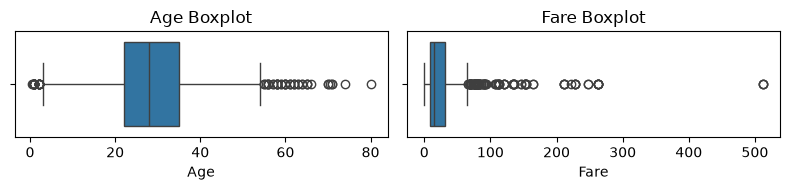

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age', 'Fare']

print(num_cols)

plt.figure(figsize=(8, 2))

for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")

plt.tight_layout()
plt.show()

In [34]:
num_cols = ['Age', 'Fare']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    lower_outliers = df[df[col] < lower_fence][col].values
    upper_outliers = df[df[col] > upper_fence][col].values

    print(f"\nColumn: {col}")
    print("Lower Fence:", lower_fence)
    print("Upper Fence:", upper_fence)
    print("Lower Outliers:", lower_outliers)
    print("Upper Outliers:", upper_outliers)


Column: Age
Lower Fence: 2.5
Upper Fence: 54.5
Lower Outliers: [2.   2.   0.83 2.   1.   1.   1.   2.   2.   0.92 2.   1.   1.   0.75
 2.   2.   2.   0.75 0.67 1.   0.42 2.   1.   0.83]
Upper Outliers: [58.  55.  66.  65.  59.  71.  70.5 55.5 61.  56.  58.  59.  62.  58.
 63.  65.  61.  60.  64.  65.  56.  63.  58.  55.  71.  64.  62.  62.
 60.  61.  57.  80.  56.  58.  70.  60.  60.  70.  57.  74.  56. ]

Column: Fare
Lower Fence: -26.7605
Upper Fence: 65.6563
Lower Outliers: []
Upper Outliers: [ 71.2833 263.     146.5208  82.1708  76.7292  83.475   73.5    263.
  77.2875 247.5208  73.5     77.2875  79.2     66.6     69.55    69.55
 146.5208  69.55   113.275   76.2917  90.      83.475   90.      79.2
  86.5    512.3292  79.65   153.4625 135.6333  77.9583  78.85    91.0792
 151.55   247.5208 151.55   110.8833 108.9     83.1583 262.375  164.8667
 134.5     69.55   135.6333 153.4625 133.65    66.6    134.5    263.
  75.25    69.3    135.6333  82.1708 211.5    227.525   73.5    120.
 113

In [35]:
df[col] = df[col].replace(lower_outliers, lower_fence)
df[col] = df[col].replace(upper_outliers, upper_fence)

In [36]:
def plot_num_boxplots(df):
    num_cols = ['Age', 'Fare']
    plt.figure(figsize=(8, 2))

    for i, col in enumerate(num_cols):
      plt.subplot(1, 2, i + 1)
      sns.boxplot(x=df[col])
      plt.title(f"{col} Boxplot")

    return plt.show()


In [37]:
df.duplicated().sum()

np.int64(123)

In [38]:
df = df.drop_duplicates()

In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
def remove_duplicated_records(df, subset_cols = None, keep_strategy = "first"):
    count = df.duplicated().sum()
    print(count)
    
    return (df.drop_duplicates(subset=subset_cols, keep=keep_strategy).reset_index(drop = True))
 

In [41]:
remove_duplicated_records(df)

0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,65.6563,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
761,0,3,female,39.0,0,5,29.1250,Q
762,1,1,female,19.0,0,0,30.0000,S
763,0,3,female,28.0,1,2,23.4500,S
764,1,1,male,26.0,0,0,30.0000,C


In [42]:
num_cols

['Age', 'Fare']

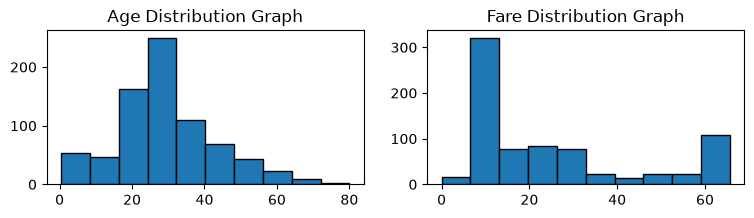

In [43]:
plt.figure(figsize =(9,2))
for i ,col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    plt.hist(df[col], edgecolor = "black")
    plt.title(f"{col} Distribution Graph")

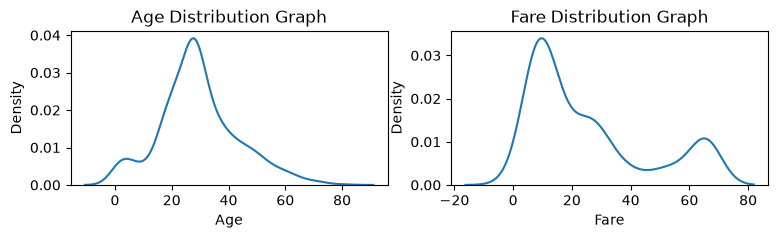

In [44]:
plt.figure(figsize =(9,2))
for i ,col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} Distribution Graph")

In [45]:
cat_cols = df.select_dtypes("category").columns
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='str')

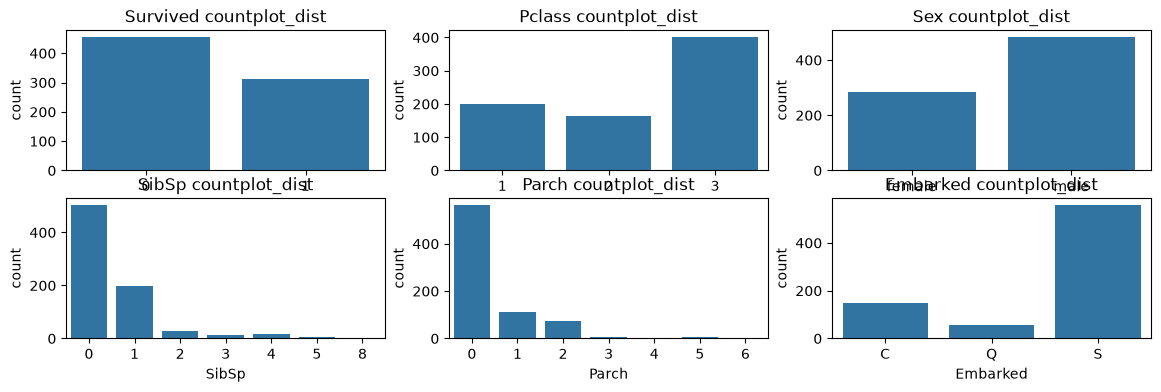

In [46]:

cat_cols = ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']
plt.figure(figsize=(14,4))
for i ,col in enumerate(cat_cols):
    plt.subplot(2,3, i+1)
    sns.countplot(x = col ,data = df)
    plt.title(f"{col} countplot_dist")

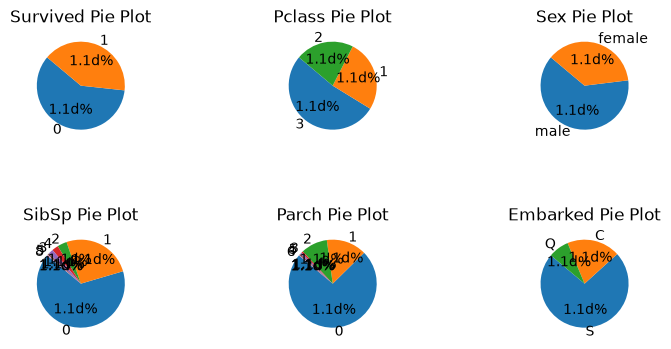

In [47]:
cat_cols
plt.figure(figsize = (9,4))
for i ,col in enumerate(cat_cols):
    plt.subplot(2,3,i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories = unique.index
    plt.pie(count , labels= categories , startangle=140 , autopct= '1.1d%%')
    plt.title(f"{col} Pie Plot")
plt .subplots_adjust(hspace= 0.8, wspace=0.3) 
plt.show()   


In [48]:
unique = df[col].value_counts()
count = unique.values
count


array([558, 150,  58])

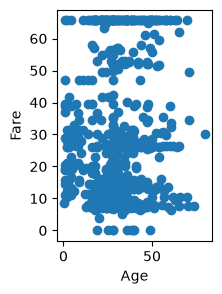

In [49]:
plt.figure(figsize=(2,3))
plt.scatter(df['Age'],df['Fare'])
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

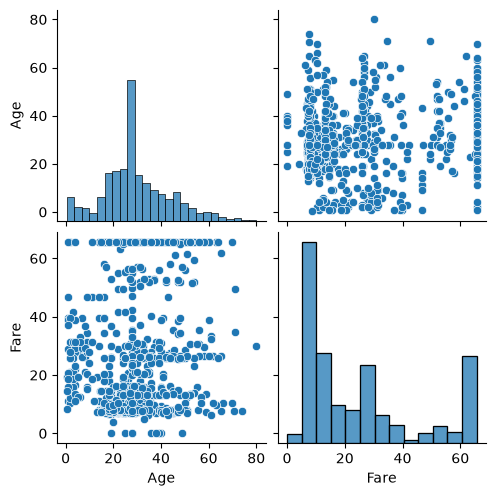

In [50]:
sns.pairplot(df)

In [51]:
corr_1 = df.corr(numeric_only=True)
corr_1

,Age,Fare
Age,1.000000,0.138849
Fare,0.138849,1.000000


<Axes: xlabel='Survived', ylabel='Fare'>

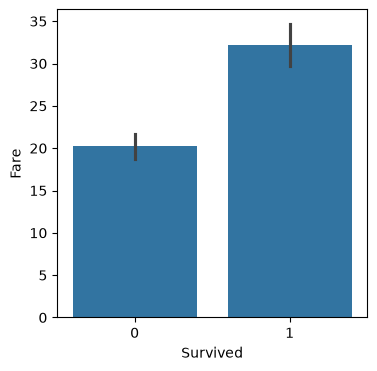

In [52]:
plt.figure(figsize=(4,4))
sns.barplot(x = "Survived" , y = "Fare" ,data =df)


In [53]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,65.6563,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [54]:
x = df.drop("Survived" , axis =1)
y = df[["Survived"]]

In [55]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,65.6563,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [56]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
885,0
887,1
888,0
889,1


In [57]:
pip  install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [58]:
pip  install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [59]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(x[num_cols])
x[num_cols] = scaler.transform(x[num_cols])
x[num_cols]

,Age,Fare
0,0.271174,0.110424
1,0.472229,1.000000
2,0.321438,0.120704
3,0.434531,0.808757
4,0.434531,0.122608
...,...,...
885,0.484795,0.443598
887,0.233476,0.456925
888,0.346569,0.357163
889,0.321438,0.456925


In [60]:
pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [61]:
str_cols = ['Sex','Embarked']

In [62]:
from category_encoders import OneHotEncoder
encoder = OneHotEncoder(cols = str_cols , drop_invariant = True)
x = encoder.fit_transform(x)


In [63]:
x.head()

,Pclass,Sex_1,Sex_2,Age,SibSp,Parch,Fare,Embarked_1,Embarked_2,Embarked_3
0,3,1,0,0.271174,1,0,0.110424,1,0,0
1,1,0,1,0.472229,1,0,1.000000,0,1,0
2,3,0,1,0.321438,0,0,0.120704,1,0,0
3,1,0,1,0.434531,1,0,0.808757,1,0,0
4,3,1,0,0.434531,0,0,0.122608,1,0,0


In [64]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [65]:
import plotly.express as px
import plotly.graph_objects as go

In [66]:
%pip install -U nbformat

Note: you may need to restart the kernel to use updated packages.


In [74]:
fig = px.pie(df,
             names='Survived',
             title = "<b> survived disribution </b>",
             color_discrete_sequence=px.colors.qualitative.Pastel,
             hole = 0.4)
#fig.update_traces(textinfo = "percent + lable") 
fig.update_layout(annotations = [dict(text = "Survived", font_size = 20 ,x = .5 ,y = .5 , showarrow = False)])            
fig.show()
 

In [76]:
px.histogram(df , x = 'Survived' , color = 'Sex' , title = "<b> Survived based on Gender <\b>", barmode = 'group')

In [80]:
fig = px.scatter(df , x = 'Age' , y = 'Fare' ,title = 'Scatter plot ' , opacity= .2   )
fig.show()